In [120]:
from google.colab import files
uploaded = files.upload()


Saving Bank_Churn.csv to Bank_Churn (2).csv


In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [122]:
df=pd.read_csv("Bank_Churn.csv")

In [123]:
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [124]:
df_eda=df.copy()

In [125]:
df_eda

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


#**SO WE WILL DO ANALYSIS ON 2ND DATAFRAME AND MAKE MODEL BUILDING ON ORGINAL DATAFRAME**

In [126]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [127]:
df_eda.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [128]:
df_eda.isnull().sum()

,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0


In [129]:
df_eda.duplicated().sum()

np.int64(0)

In [130]:
df_eda.drop(columns=['CustomerId','Surname'],inplace=True)

In [131]:
df_eda

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [132]:
from sklearn.preprocessing import OneHotEncoder

In [133]:
df_eda=pd.get_dummies(df_eda,columns=['Geography','Gender'],drop_first=True).astype(int)


In [134]:
df_eda

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,1,0,0,0
1,608,41,1,83807,1,0,1,112542,0,0,1,0
2,502,42,8,159660,3,1,0,113931,1,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0,0
4,850,43,2,125510,1,1,1,79084,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0,2,1,0,96270,0,0,0,1
9996,516,35,10,57369,1,1,1,101699,0,0,0,1
9997,709,36,7,0,1,0,1,42085,1,0,0,0
9998,772,42,3,75075,2,1,0,92888,1,1,0,1


<Axes: >

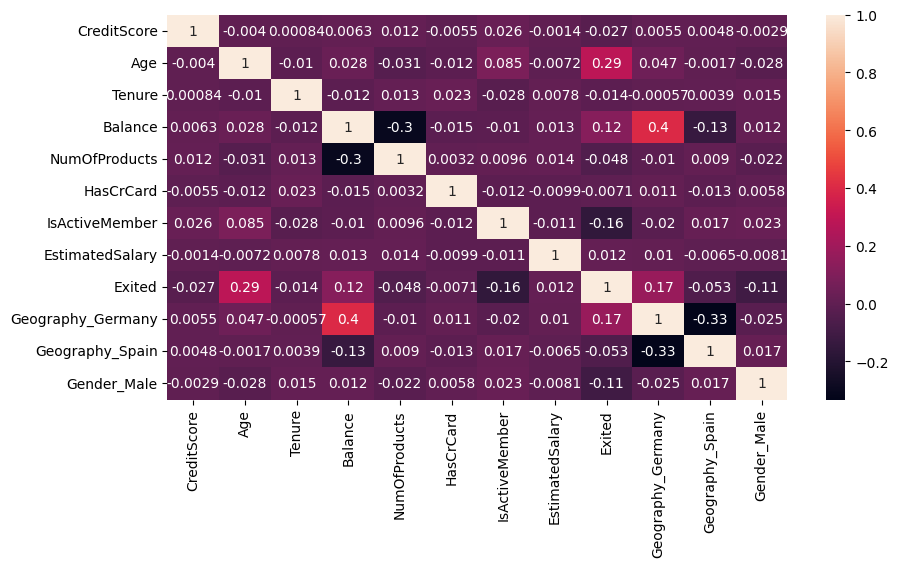

In [135]:
cor=df_eda.corr()
fig,ax=plt.subplots(figsize=(10,5))
sns.heatmap(df_eda.corr(),annot=True,ax=ax)

<Axes: >

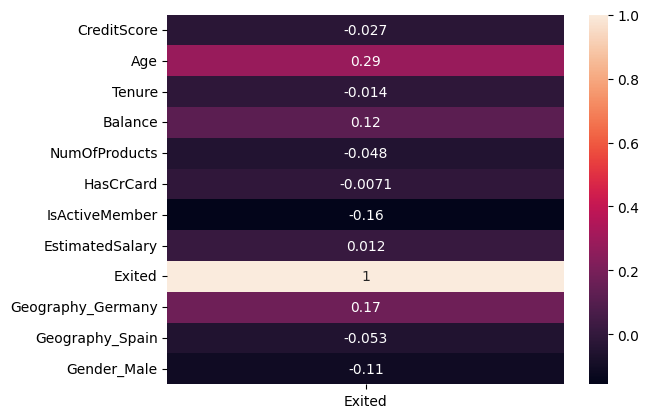

In [136]:
cor=df_eda.corr()[['Exited']]
sns.heatmap(cor,annot=True)

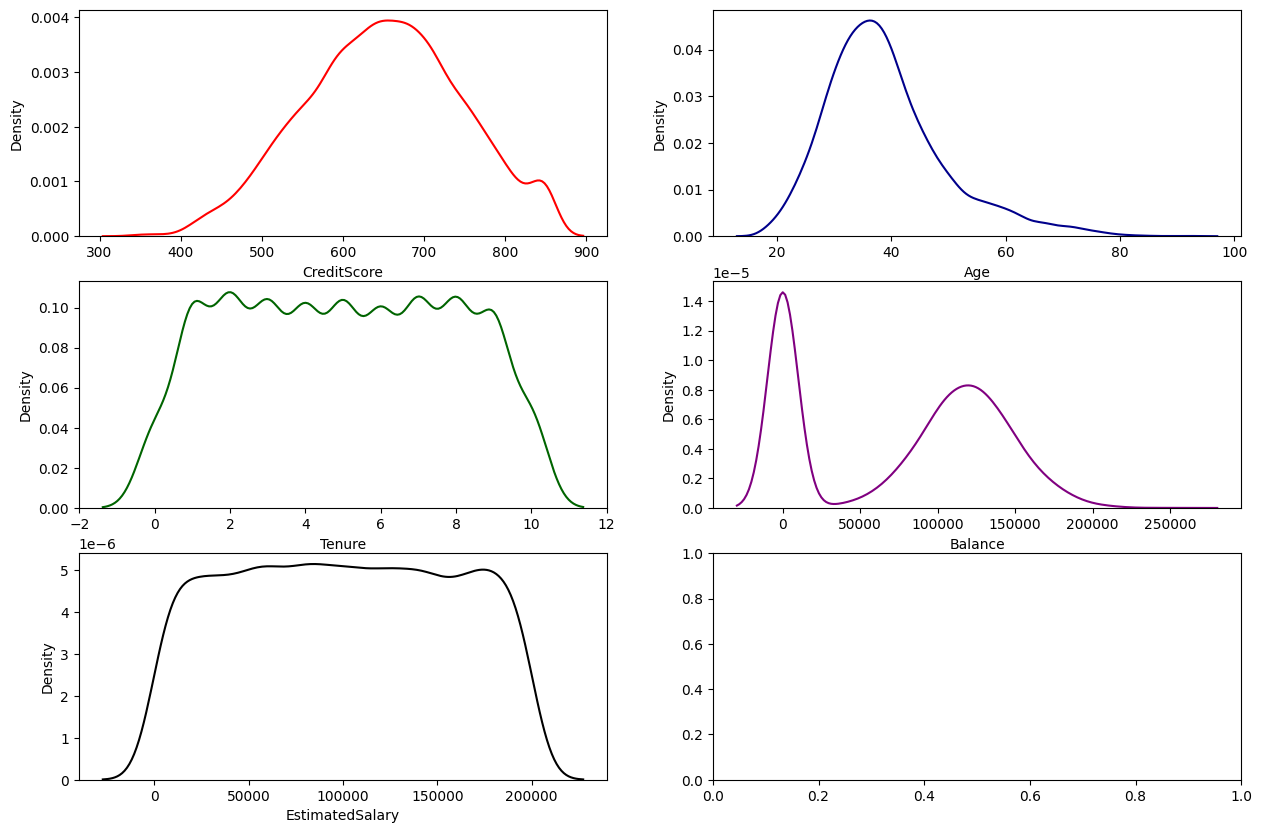

In [137]:
num_col=['CreditScore', 'Age', 'Tenure', 'Balance',  'EstimatedSalary']
color=['Red','Darkblue','Darkgreen','Purple','Black']
fig,axes=plt.subplots(3,2,figsize=(15,10))
axes=axes.flatten()
for i,col in enumerate(num_col):
  sns.kdeplot(data=df_eda,x=col,ax=axes[i],color=color[i])
  ax.set_xlabel=col

# Key Insights:
- CreditScore: CreditScore shows normal distribution here.
- Age: Age shows Left skewness a bit.
- Tenure: Shows nomrla distribution.
- Balance: Shows bimodel distribution



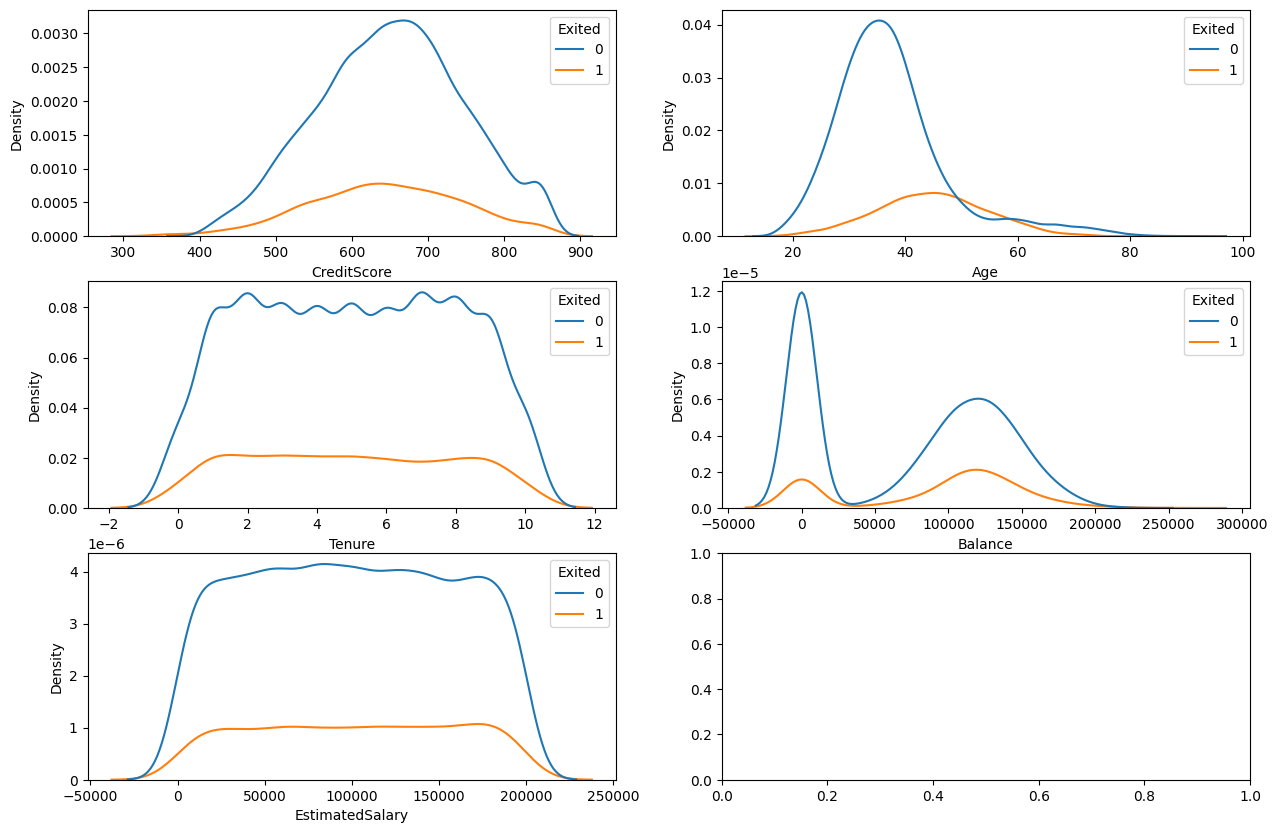

In [138]:
num_col=['CreditScore', 'Age', 'Tenure', 'Balance',  'EstimatedSalary']

fig,axes=plt.subplots(3,2,figsize=(15,10))
axes=axes.flatten()
for i,col in enumerate(num_col):
  sns.kdeplot(data=df_eda,x=col,ax=axes[i],color=color[i],hue='Exited')
  ax.set_xlabel=col

# Age shows us the one thing that when the age is approx is  45 years people shows more excitement


In [139]:
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


([<matplotlib.patches.Wedge at 0x7afc7d5d6480>,
 [Text(-0.9625562432069147, 0.716579010761124, 'Not Exited'),
  Text(0.8823431237559431, -0.6568642264278096, 'Exited')],
 [Text(-0.5614911418707002, 0.418004422943989, '79.6%'),
  Text(0.48127806750324165, -0.35828957805153244, '20.4%')])

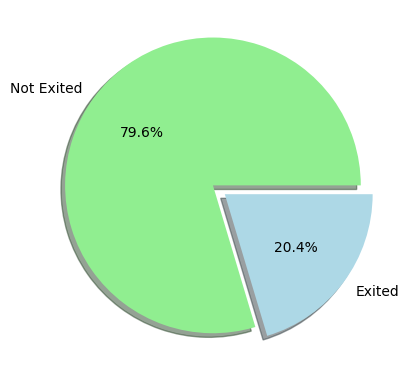

In [140]:
plt.pie(df['Exited'].value_counts(),autopct='%0.1f%%',labels=['Not Exited','Exited'],colors=['lightgreen','lightblue'],explode=[0.1,0],shadow=True)

# Data is a bit unbalanced but not severe so no need of any kind of smote or other technologies to balance the data




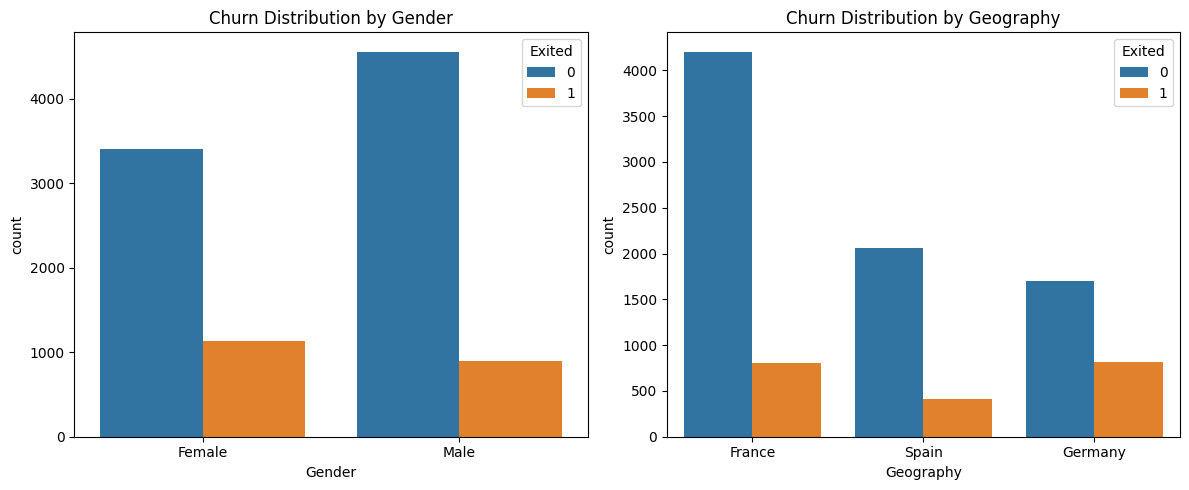

In [141]:
cat_cols = ['Gender', 'Geography']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], hue='Exited')
    axes[i].set_xlabel(col)
    axes[i].set_title(f'Churn Distribution by {col}')

plt.tight_layout()
plt.show()

In [142]:
df.groupby("NumOfProducts")['Exited'].value_counts()

NumOfProducts  Exited
1              0         3675
               1         1409
2              0         4242
               1          348
3              1          220
               0           46
4              1           60
Name: count, dtype: int64

<Axes: xlabel='NumOfProducts', ylabel='count'>

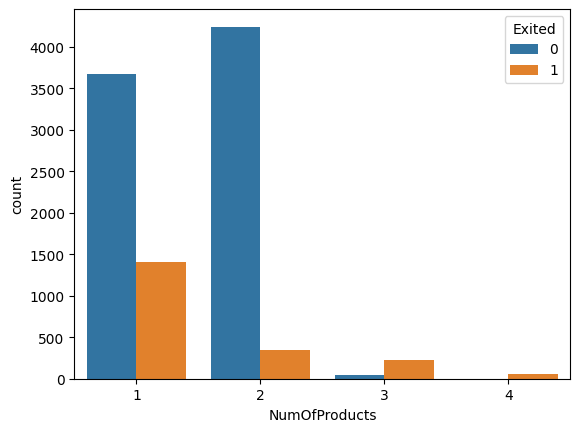

In [143]:
sns.countplot(data=df,x='NumOfProducts',hue='Exited')

# Interpretation
### Gender
- Females have higher churn rate (25.1%) than males (16.5%)
- Even though males are more in number, they leave less proportionally
### Geography
-  Germany has very high churn rate (32.4%)
- France and Spain are almost similar (~16-17%)
### Number of products
- Customers with 2 products are most stable (lowest churn)
- Customers with 3 or 4 products have extremely high churn
- 4 products -> all customers left

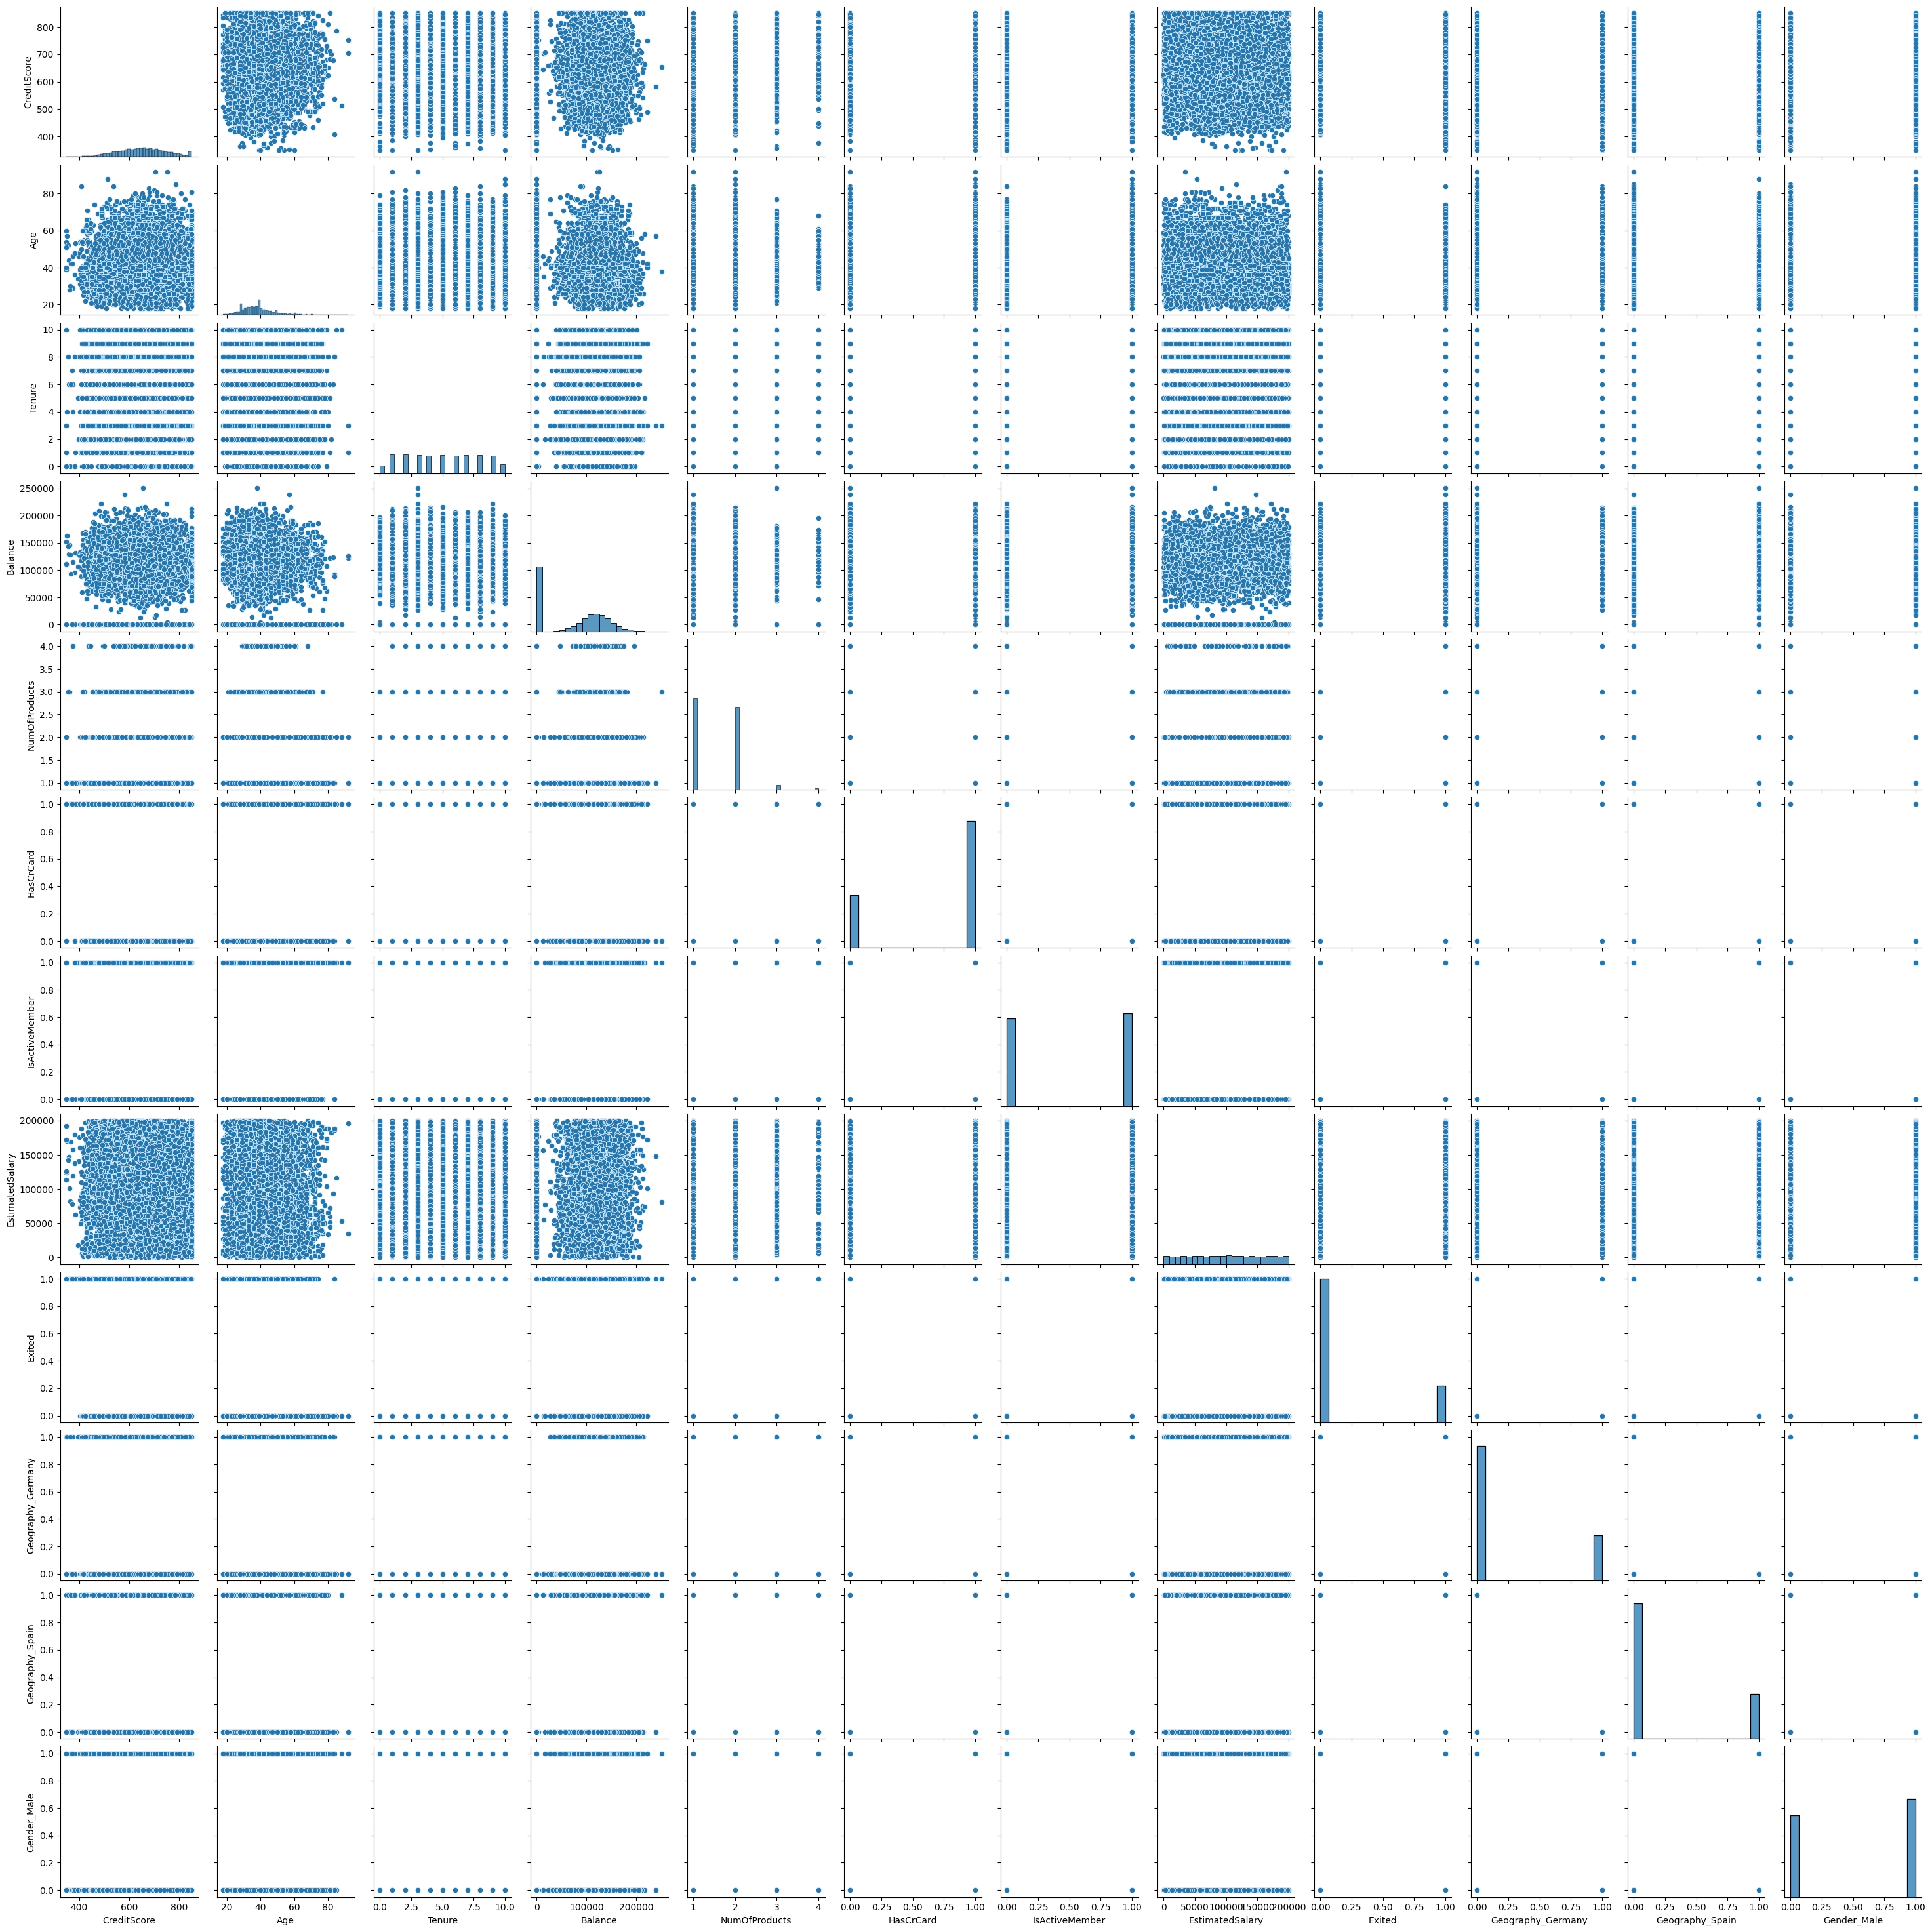

In [144]:
sns.pairplot(df_eda)

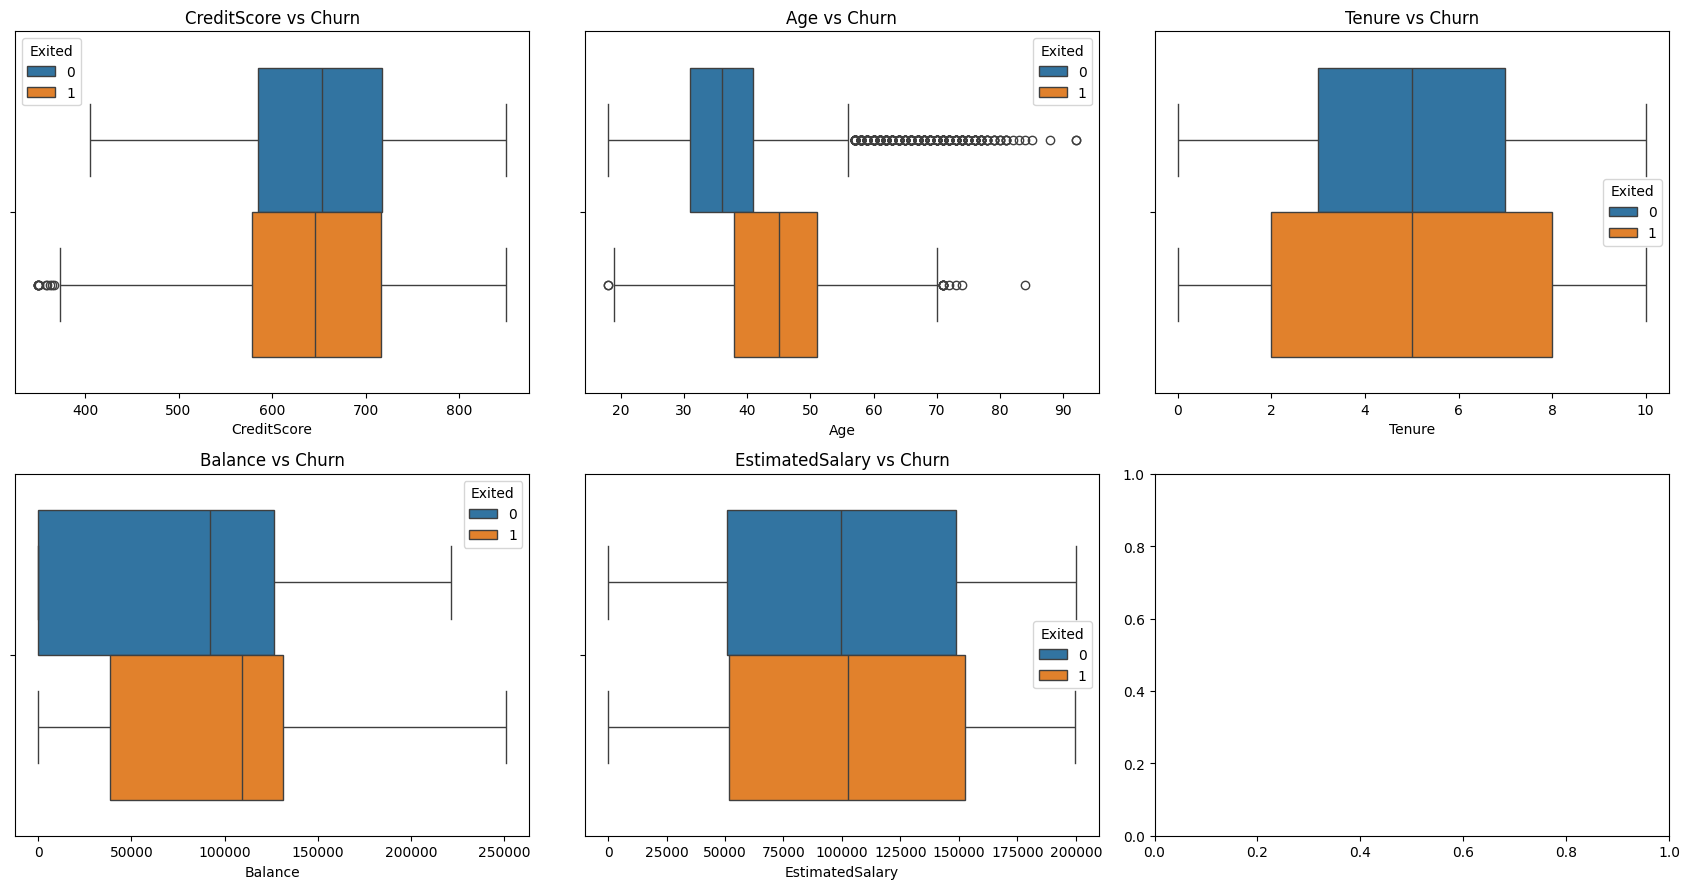

In [145]:
num_col=['CreditScore', 'Age', 'Tenure', 'Balance',  'EstimatedSalary']

fig,axes=plt.subplots(2,3,figsize=(17,9))
axes=axes.flatten()
for i,col in enumerate(num_col):
  sns.boxplot(data=df_eda,x=col,ax=axes[i],hue='Exited')
  axes[i].set_xlabel=col
  axes[i].set_title(f'{col} vs Churn')
plt.tight_layout()

 # Key Insight:
 #### Age and Balance show the most separation between churned and retained customers, making them the most important numerical features for churn prediction.

In [146]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                  'HasCrCard', 'IsActiveMember', 'EstimatedSalary','Gender_Male','Geography_Spain','Geography_Germany']

X = df_eda[numerical_cols].dropna()


vif_data = pd.DataFrame()
vif_data['Feature'] = numerical_cols
vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)



In [147]:
vif_data


,Feature,VIF
0,CreditScore,21.236433
1,Age,12.334127
2,NumOfProducts,7.826415
3,EstimatedSalary,3.887159
4,Tenure,3.872754
5,HasCrCard,3.289605
6,Balance,3.182263
7,Gender_Male,2.168988
8,IsActiveMember,2.075966
9,Geography_Germany,1.787169


In [148]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix,f1_score,recall_score,precision_score

In [149]:

x=df.drop(columns=['Exited','CustomerId','Surname','CreditScore'])
y=df['Exited']


In [150]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y,shuffle=True)

In [151]:
columns=["Gender","Geography"]

In [152]:
col_transfomer=ColumnTransformer(transformers=[
    ('onehot',OneHotEncoder(),columns)
],remainder='passthrough')

In [153]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
print(neg / pos)

3.9079754601226995


In [154]:
pipeline_xgboost = ImbPipeline([
    ('col_transfomer', col_transfomer),

    ('model', XGBClassifier(
                n_estimators=200,
                max_depth=4,
                learning_rate=0.1,
                scale_pos_weight=3.9,
                eval_metric='auc',
                random_state=42))
])

In [155]:
params_grid_xgboost = [{
    'model__n_estimators': [100,150,200,250],
    'model__max_depth': [3,4,5,6,7],
    'model__learning_rate': [0.01,0.05,0.1,0.2]

    }]


In [156]:
grid_xg=GridSearchCV(pipeline_xgboost,param_grid=params_grid_xgboost,cv=5,scoring='roc_auc',n_jobs=-1)

In [157]:
best_estimator_xg=grid_xg.fit(x_train,y_train)

In [158]:
best_estimator_xg.best_score_

np.float64(0.8666559120108639)

In [159]:
best_estimator_xg.best_params_

{'model__learning_rate': 0.1,
 'model__max_depth': 3,
 'model__n_estimators': 150}

In [160]:
y_prob_xg = best_estimator_xg.predict_proba(x_test)[:, 1]
y_pred_xg = (y_prob_xg > 0.5).astype(int)

print("AUC-ROC:  ", roc_auc_score(y_test, y_prob_xg))
print("F1:       ", f1_score(y_test, y_pred_xg))
print("Precision:", precision_score(y_test, y_pred_xg))
print("Recall:   ", recall_score(y_test, y_pred_xg))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xg))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xg))

AUC-ROC:   0.8672162146738418
F1:        0.6078431372549019
Precision: 0.5057096247960848
Recall:    0.7616707616707616

Confusion Matrix:
[[1290  303]
 [  97  310]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      1593
           1       0.51      0.76      0.61       407

    accuracy                           0.80      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.84      0.80      0.81      2000



# Findings:
- AUC is 0.867 - model is excellent at separating churners from non-churners.
- Recall is 0.76 - catching 84% of churners, missing only 66 out of 407.
- Precision is 0.5 -half the people flagged as churners are false alarms.
- F1 is 0.61 - moderate balance between precision and recall.
- Accuracy is 0.80 - overall correct 80% of the time.
- Confusion matrix - 303 churners correctly caught, 97 missed, 310 loyal customers wrongly flagged.

In [161]:
pipeline_xgboost_s = ImbPipeline([
    ('col_transfomer', col_transfomer),
    ('smote',SMOTE(random_state=42,sampling_strategy=0.8,)),
    ('model', XGBClassifier(
                n_estimators=200,
                max_depth=4,
                learning_rate=0.1,
                scale_pos_weight=1,
                eval_metric='auc',
                random_state=42))
])

In [162]:
params_grid_xgboost= [{
    'model__n_estimators': [100,150,200,250],
    'model__max_depth': [3,4,5,6,7],
    'model__learning_rate': [0.01,0.05,0.1,0.2]

    }]


In [163]:
grid_xg_s=GridSearchCV(pipeline_xgboost_s,param_grid=params_grid_xgboost,cv=5,scoring='roc_auc',n_jobs=-1)

In [164]:
best_estimator_xg_s=grid_xg_s.fit(x_train,y_train)

In [165]:
best_estimator_xg_s.best_estimator_

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('col_transfomer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehot', OneHotEncoder(),
                                                  ['Gender', 'Geography'])])),
                ('smote', SMOTE(random_state=42, sampling_strategy=0.8)),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [166]:
best_estimator_xg_s.best_score_

np.float64(0.8663908177711857)

In [167]:
y_prob_xg_s = best_estimator_xg_s.predict_proba(x_test)[:, 1]

y_pred_xg_s=(y_prob_xg_s>0.5).astype(int)



In [168]:
print("AUC-ROC:  ", roc_auc_score(y_test, y_prob_xg_s))
print("F1:       ", f1_score(y_test, y_pred_xg_s))
print("Precision:", precision_score(y_test, y_pred_xg_s))
print("Recall:   ", recall_score(y_test, y_pred_xg_s))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xg_s))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xg_s))

AUC-ROC:   0.8663023578277815
F1:        0.6191860465116279
Precision: 0.7580071174377224
Recall:    0.5233415233415234

Confusion Matrix:
[[1525   68]
 [ 194  213]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      1593
           1       0.76      0.52      0.62       407

    accuracy                           0.87      2000
   macro avg       0.82      0.74      0.77      2000
weighted avg       0.86      0.87      0.86      2000



#SPW            SMOTE
- AUC          -    0.867  -         0.866   -> tie
- Recall        -   0.762   -        0.523   -> SPW wins
- Precision      -  0.506    -       0.758   -> SMOTE wins
- F1              - 0.608     -      0.619   -> SMOTE wins slightly
- Accuracy         -0.80       -     0.87    -> SMOTE wins
- Churners caught   -310        -     213    ->SPW wins
- Missed             -97         -    194    -> SPW wins
- False alarms      -303          -    68    -> SMOTE wins

#SMOTE = precise but misses too many churners. SPW = catches more churners but noisier. For a bank wanting to retain customers - SPW is the better choice here